In [118]:
import os

DATASET_PATH = "/kaggle/input/datasets/pragya002/facial-emotion-recognition"

train_dir = os.path.join(DATASET_PATH, "train")
test_dir = os.path.join(DATASET_PATH, "test")

print("Dataset Path Exists :", os.path.exists(DATASET_PATH))
print("Train Path Exists   :", os.path.exists(train_dir))
print("Test Path Exists    :", os.path.exists(test_dir))

print("\nTrain Classes:")
print(sorted(os.listdir(train_dir)))

print("\nTest Classes:")
print(sorted(os.listdir(test_dir)))

Dataset Path Exists : True
Train Path Exists   : True
Test Path Exists    : True

Train Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [119]:
import os

print("=" * 50)
print("TRAIN DATASET")
print("=" * 50)

train_total = 0

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        train_total += count
        print(f"{cls:<10} : {count}")

print("\nTotal Train Images :", train_total)


print("\n" + "=" * 50)
print("TEST DATASET")
print("=" * 50)

test_total = 0

for cls in sorted(os.listdir(test_dir)):
    cls_path = os.path.join(test_dir, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        test_total += count
        print(f"{cls:<10} : {count}")

print("\nTotal Test Images :", test_total)

TRAIN DATASET
angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171

Total Train Images : 28709

TEST DATASET
angry      : 958
disgust    : 111
fear       : 1024
happy      : 1774
neutral    : 1233
sad        : 1247
surprise   : 831

Total Test Images : 7178


In [120]:
import os
from PIL import Image
import numpy as np

sample_info = []

for cls in sorted(os.listdir(train_dir)):
    
    cls_path = os.path.join(train_dir, cls)
    
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    arr = np.array(img)

    print(f"\nClass: {cls}")
    print("Image Name :", img_name)
    print("Mode       :", img.mode)
    print("Shape      :", arr.shape)
    print("Datatype   :", arr.dtype)

    sample_info.append(arr.shape)


Class: angry
Image Name : Training_52322132.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8

Class: disgust
Image Name : Training_54996784.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8

Class: fear
Image Name : Training_80689648.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8

Class: happy
Image Name : Training_65647822.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8

Class: neutral
Image Name : Training_98425931.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8

Class: sad
Image Name : Training_89959053.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8

Class: surprise
Image Name : Training_66056468.jpg
Mode       : L
Shape      : (48, 48)
Datatype   : uint8


In [121]:
import os
from PIL import Image
from collections import Counter

shapes = Counter()
corrupted = []

for split in [train_dir, test_dir]:

    split_name = os.path.basename(split)

    for cls in os.listdir(split):

        cls_path = os.path.join(split, cls)

        if not os.path.isdir(cls_path):
            continue

        for img_name in os.listdir(cls_path):

            img_path = os.path.join(cls_path, img_name)

            try:
                img = Image.open(img_path)
                shapes[img.size] += 1

            except Exception:
                corrupted.append(img_path)

print("Unique Image Sizes:")
print(shapes)

print("\nNumber of Corrupted Images:")
print(len(corrupted))

if len(corrupted) > 0:
    print("\nFirst 10 Corrupted Files:")
    print(corrupted[:10])

Unique Image Sizes:
Counter({(48, 48): 35887})

Number of Corrupted Images:
0


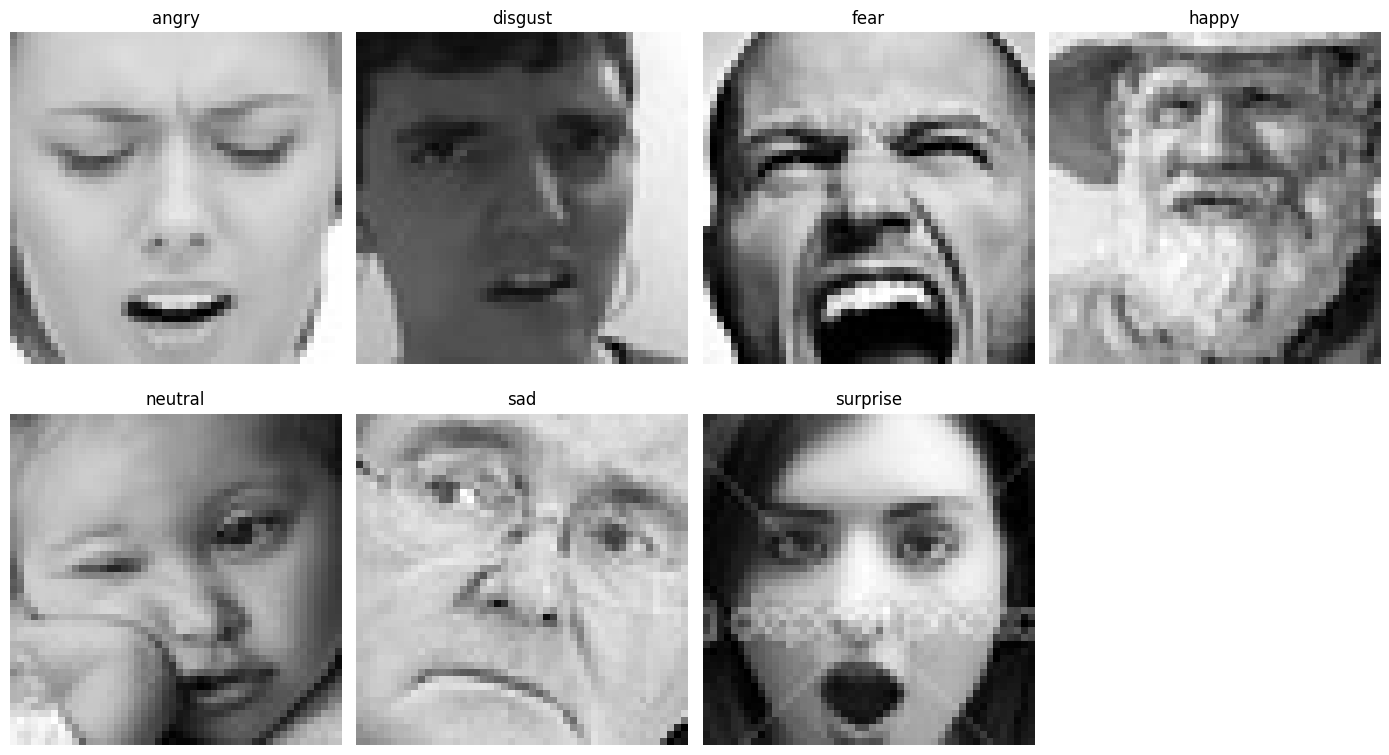

In [122]:
import os
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(14, 8))

for i, cls in enumerate(classes):

    img_name = os.listdir(os.path.join(train_dir, cls))[0]
    img_path = os.path.join(train_dir, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [123]:
import numpy as np
from PIL import Image
import os

sample_pixels = []

for cls in sorted(os.listdir(train_dir)):
    
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path)[:200]:
        
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path)
        arr = np.array(img)

        sample_pixels.append(arr)

sample_pixels = np.concatenate(
    [x.flatten() for x in sample_pixels]
)

print("Min Pixel :", sample_pixels.min())
print("Max Pixel :", sample_pixels.max())
print("Mean      :", round(sample_pixels.mean(), 2))
print("Std       :", round(sample_pixels.std(), 2))

Min Pixel : 0
Max Pixel : 255
Mean      : 129.5
Std       : 65.32


In [124]:
import os
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_names = sorted(os.listdir(train_dir))

labels = []

for idx, cls in enumerate(class_names):

    cls_path = os.path.join(train_dir, cls)

    labels.extend([idx] * len(os.listdir(cls_path)))

labels = np.array(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    i: float(w)
    for i, w in enumerate(weights)
}

print("Classes:")
print(class_names)

print("\nClass Weights:")
print(class_weights)

Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class Weights:
{0: 1.0266046844269623, 1: 9.406618610747051, 2: 1.0010460615781582, 3: 0.5684387684387684, 4: 0.8260394187886635, 5: 0.8491274770777877, 6: 1.293372978330405}


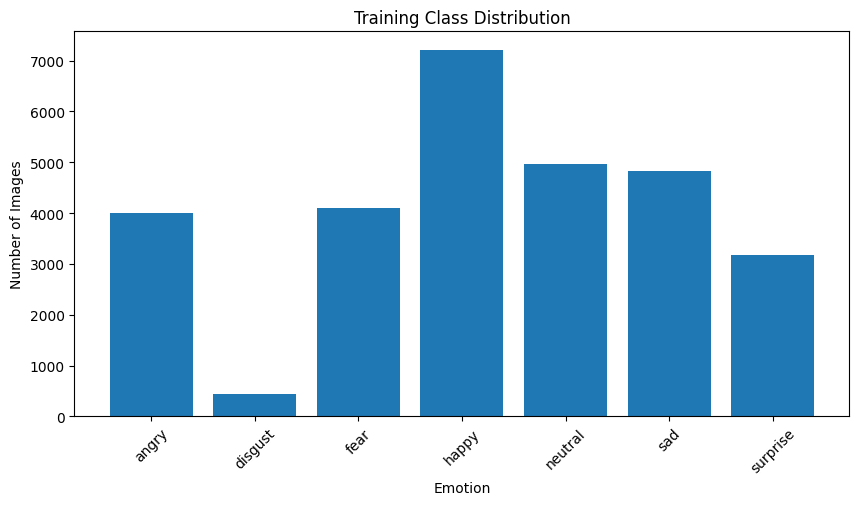

In [125]:
import os
import matplotlib.pyplot as plt

classes = sorted(os.listdir(train_dir))
counts = []

for cls in classes:
    counts.append(len(os.listdir(os.path.join(train_dir, cls))))

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.title("Training Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [126]:
import tensorflow as tf

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

class_names = train_ds.class_names

print("Classes:")
print(class_names)

print("\nTrain batches:", len(train_ds))
print("Validation batches:", len(val_ds))


Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Train batches: 359
Validation batches: 90


In [127]:
for images, labels in train_ds.take(1):

    print("Images Shape :", images.shape)
    print("Labels Shape :", labels.shape)

    print("\nSample Labels:")
    print(labels[:10].numpy())

    break

Images Shape : (64, 48, 48, 1)
Labels Shape : (64,)

Sample Labels:
[5 3 3 5 2 3 3 3 5 3]


In [128]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

print("Pipeline created successfully.")

Pipeline created successfully.


In [129]:
for images, labels in train_ds.take(1):

    print("Min Pixel:", tf.reduce_min(images).numpy())
    print("Max Pixel:", tf.reduce_max(images).numpy())
    print("Mean     :", tf.reduce_mean(images).numpy())

    break

Min Pixel: 0.0
Max Pixel: 1.0
Mean     : 0.4793321


In [130]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(48, 48, 1)),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.GlobalAveragePooling2D(),

    # Classifier
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dropout(0.4),

    layers.Dense(7, activation='softmax')
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 12, 12, 128)    │             

 Total params: 324,071 (1.24 MB)

 Trainable params: 322,663 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [131]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [132]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        'best_baseline.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

print("Callbacks ready")

Callbacks ready


In [133]:
train_ds = train_ds.map(
    lambda x, y: (
        normalization(data_augmentation(x, training=True)),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (
        normalization(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

In [134]:
import tensorflow as tf

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [135]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.2618 - loss: 1.9037 - val_accuracy: 0.2566 - val_loss: 1.8676 - learning_rate: 0.0010
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3966 - loss: 1.5686 - val_accuracy: 0.3917 - val_loss: 1.5830 - learning_rate: 0.0010
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4751 - loss: 1.3732 - val_accuracy: 0.4261 - val_loss: 1.4825 - learning_rate: 0.0010
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5197 - loss: 1.2635 - val_accuracy: 0.5013 - val_loss: 1.3225 - learning_rate: 0.0010
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5400 - loss: 1.2121 - val_accuracy: 0.4048 - val_loss: 1.7618 - learning_rate: 0.0010
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5597 - loss: 1.1696 - val_accuracy: 0.3844 - val_loss: 1.8656 - learning_rate: 0.0010
Epoch 7/100
356/359 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5699 - 

In [136]:
for images, labels in test_ds.take(1):

    preds = model.predict(images, verbose=0)

    print(preds[0])
    print("Sum =", preds[0].sum())

    break


[0.3412559  0.00276292 0.067538   0.00541999 0.01765381 0.5540969
 0.01127249]
Sum = 1.0


In [137]:
val_loss, val_acc = model.evaluate(
    val_ds,
    verbose=1
)

print("Validation Accuracy =", val_acc)

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6276 - loss: 1.0380
Validation Accuracy = 0.6275910139083862


In [138]:
import numpy as np

test_labels = []

for _, labels in test_ds:
    test_labels.extend(labels.numpy())

unique, counts = np.unique(test_labels, return_counts=True)

print("Test Label Distribution")

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Test Label Distribution
Class 0: 958
Class 1: 111
Class 2: 1024
Class 3: 1774
Class 4: 1233
Class 5: 1247
Class 6: 831


In [139]:
y_true = []
y_pred = []

for images, labels in val_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.5192    0.5740    0.5452       777
           1     0.3889    0.5753    0.4641        73
           2     0.5000    0.3978    0.4431       812
           3     0.8565    0.8046    0.8297      1402
           4     0.5460    0.6770    0.6045      1000
           5     0.5343    0.4538    0.4908       996
           6     0.7379    0.7856    0.7610       681

    accuracy                         0.6276      5741
   macro avg     0.5833    0.6097    0.5912      5741
weighted avg     0.6304    0.6276    0.6257      5741



In [140]:
for images, labels in test_ds.take(1):

    preds = model.predict(images, verbose=0)

    for i in range(5):
        print("True:", labels[i].numpy())
        print("Probabilities:", np.round(preds[i], 3))
        print("Pred:", np.argmax(preds[i]))
        print("-" * 40)

    break

True: 0
Probabilities: [0.341 0.003 0.068 0.005 0.018 0.554 0.011]
Pred: 5
----------------------------------------
True: 0
Probabilities: [0.348 0.003 0.068 0.005 0.017 0.547 0.012]
Pred: 5
----------------------------------------
True: 0
Probabilities: [0.357 0.003 0.069 0.005 0.017 0.538 0.012]
Pred: 5
----------------------------------------
True: 0
Probabilities: [0.353 0.003 0.068 0.005 0.017 0.543 0.011]
Pred: 5
----------------------------------------
True: 0
Probabilities: [0.356 0.003 0.066 0.005 0.018 0.541 0.011]
Pred: 5
----------------------------------------


In [141]:
import numpy as np

means = []

for images, labels in test_ds.take(5):

    batch_mean = tf.reduce_mean(images, axis=[1,2,3])

    means.extend(batch_mean.numpy())

print("First 20 image means:")
print(np.round(means[:20], 4))

First 20 image means:
[0.4915 0.539  0.3235 0.5133 0.527  0.7584 0.4898 0.5061 0.414  0.6104
 0.6348 0.4621 0.53   0.3976 0.6942 0.5509 0.3868 0.4065 0.5523 0.4931]


In [142]:
# Validation batch

for images, labels in val_ds.take(1):

    print("VAL")
    print("Min :", tf.reduce_min(images).numpy())
    print("Max :", tf.reduce_max(images).numpy())
    print("Mean:", tf.reduce_mean(images).numpy())

    break


# Test batch

for images, labels in test_ds.take(1):

    print("\nTEST")
    print("Min :", tf.reduce_min(images).numpy())
    print("Max :", tf.reduce_max(images).numpy())
    print("Mean:", tf.reduce_mean(images).numpy())

    break

VAL
Min : 0.0
Max : 255.0
Mean: 126.44413

TEST
Min : 0.0
Max : 1.0
Mean: 0.5016161


In [143]:
for images, labels in val_ds.take(1):

    preds = model.predict(images, verbose=0)

    print("VAL unique predictions:")
    print(np.unique(np.argmax(preds, axis=1)))

    print(
        "Image range:",
        images.numpy().min(),
        images.numpy().max()
    )

    break

VAL unique predictions:
[0 2 3 4 5 6]
Image range: 0.0 255.0


In [144]:
test_loss, test_acc = model.evaluate(test_ds_raw)

print(test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6337 - loss: 1.0215
0.6337419748306274


In [145]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.52      0.57      0.55       777
     disgust       0.39      0.58      0.46        73
        fear       0.50      0.40      0.44       812
       happy       0.86      0.80      0.83      1402
     neutral       0.55      0.68      0.60      1000
         sad       0.53      0.45      0.49       996
    surprise       0.74      0.79      0.76       681

    accuracy                           0.63      5741
   macro avg       0.58      0.61      0.59      5741
weighted avg       0.63      0.63      0.63      5741



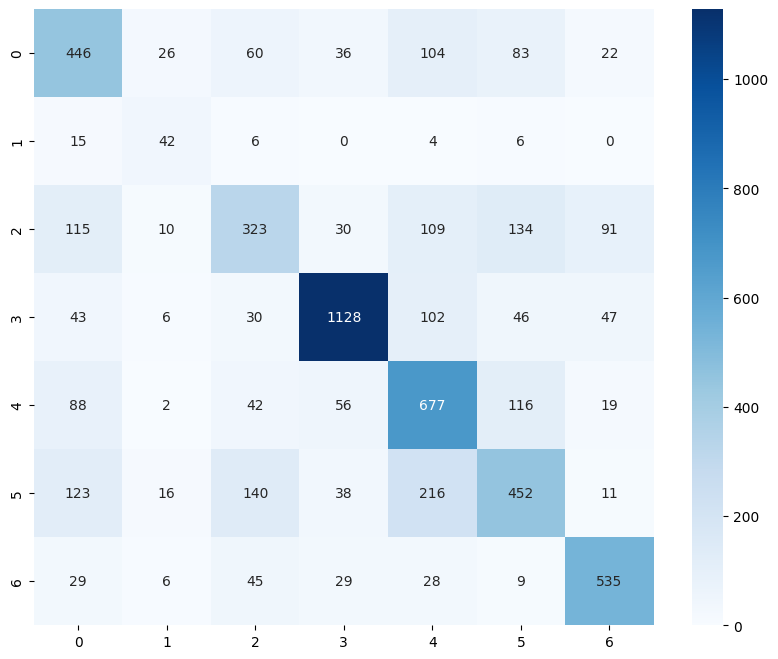

In [146]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [147]:
model.save("fer_cnn.keras")

print("Model saved successfully.")

Model saved successfully.


In [150]:
import os

print(os.path.exists("fer_cnn.keras"))

True


In [151]:
import tensorflow as tf

class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def call(self, y_true, y_pred):

        y_true = tf.cast(y_true, tf.int32)

        ce = tf.keras.losses.sparse_categorical_crossentropy(
            y_true,
            y_pred
        )

        y_true_onehot = tf.one_hot(
            y_true,
            depth=7
        )

        p_t = tf.reduce_sum(
            y_true_onehot * y_pred,
            axis=-1
        )

        focal_factor = tf.pow(
            1.0 - p_t,
            self.gamma
        )

        return focal_factor * ce


focal_loss = SparseCategoricalFocalLoss(gamma=2.0)

print("Focal loss ready.")

Focal loss ready.


In [152]:
from tensorflow.keras.models import load_model
import tensorflow as tf

model = load_model("fer_cnn.keras")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss,
    metrics=["accuracy"]
)

print("Model loaded and compiled with Focal Loss.")

Model loaded and compiled with Focal Loss.


In [153]:
model.evaluate(val_ds, verbose=1)

90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6276 - loss: 0.7268


[0.7267919778823853, 0.6275910139083862]

In [154]:
history_focal = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.7148 - loss: 0.4244 - val_accuracy: 0.6137 - val_loss: 0.7327 - learning_rate: 1.0000e-04
Epoch 2/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7099 - loss: 0.4143 - val_accuracy: 0.6048 - val_loss: 0.7146 - learning_rate: 1.0000e-04
Epoch 3/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7165 - loss: 0.4016 - val_accuracy: 0.5912 - val_loss: 0.7284 - learning_rate: 1.0000e-04
Epoch 4/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7163 - loss: 0.3988 - val_accuracy: 0.6051 - val_loss: 0.7008 - learning_rate: 1.0000e-04
Epoch 5/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7181 - loss: 0.3968 - val_accuracy: 0.5994 - val_loss: 0.6953 - learning_rate: 1.0000e-04
Epoch 6/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7173 - loss: 0.3937 - val_accuracy: 0.6069 - val_loss: 0.6782 - learning_rate: 1.0000e-04
Epoch 7/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - ac

In [155]:
print(max(history_focal.history['val_accuracy']))

0.6256749629974365
